In [1]:
# --- Header: 2D Vector Transformation ---
# Operation: Matrix-Vector Multiplication (Av)
# Dimensions: A (m x n), v (n x 1) -> Result (m x 1)
# Time Complexity: O(m * n)
#   - For 2D: O(2 * 2) = O(4) constant operations.
# Space Complexity: O(m) to store the output vector.
# Logic: Each element of the output is a dot product of a row in A and vector v.
# ----------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import math

plt.style.use('default')
# set global print options
np.set_printoptions(suppress=True, precision=3)

### 2D Transformation Matrices
In this exercise, we apply a linear transformation matrix $A$ to a 2D vector $v$. This specific matrix $A = \begin{bmatrix} 3 & -3 \\ 4 & 1 \end{bmatrix}$ performs a combination of stretching (scaling) and rotation.

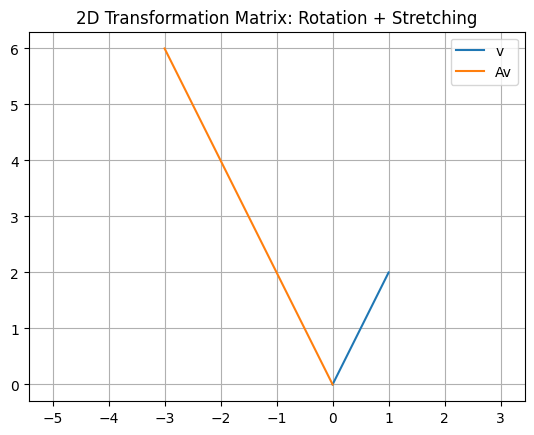

In [2]:
# 2D input vector
v = np.array([1, 2])

# 2x2 transformation matrix
A = np.array([ [3,-3], [4,1] ])

# output vector Av
Av = A@v.T

# plot both vectors
plt.plot([0, v[0]], [0, v[1]], label='v')
plt.plot([0, Av[0]], [0, Av[1]], label='Av')

plt.grid()
plt.axis('equal')
plt.legend()
plt.title('2D Transformation Matrix: Rotation + Stretching')
plt.show()

### Code Challenge: Pure and Impure Rotation Matrices

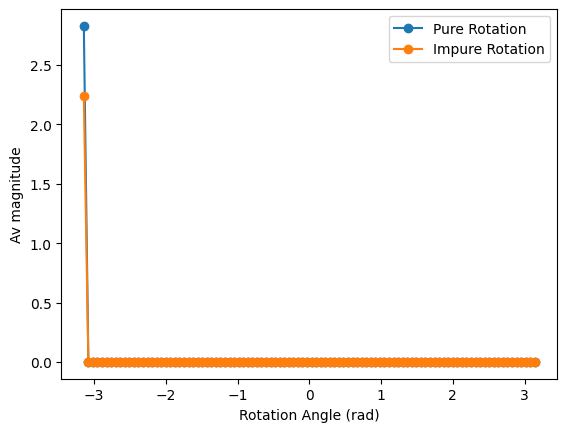

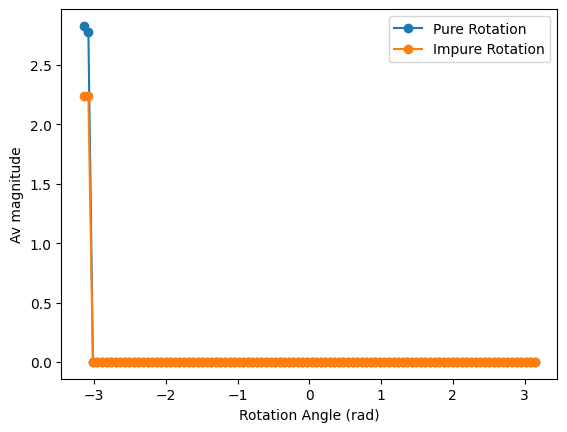

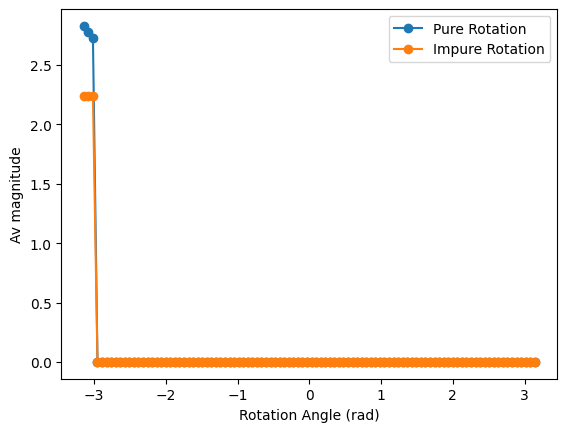

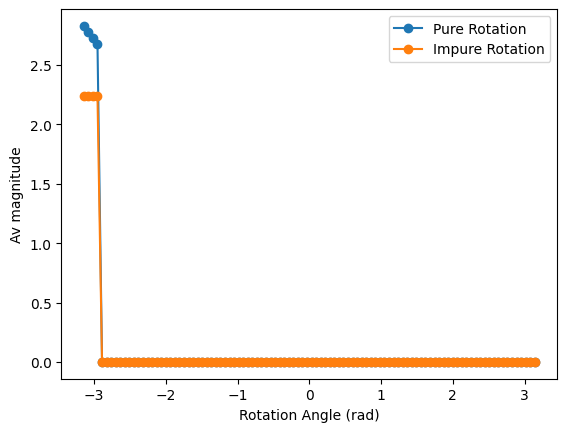

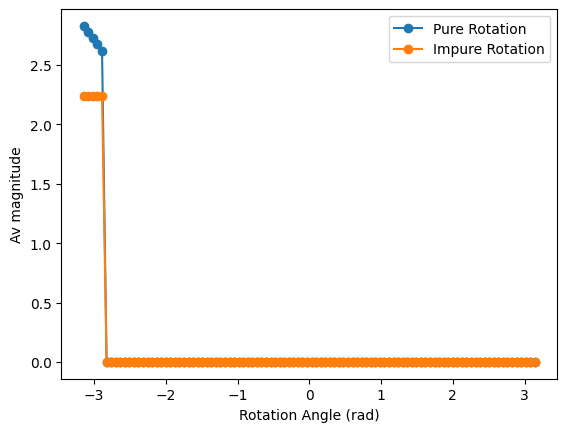

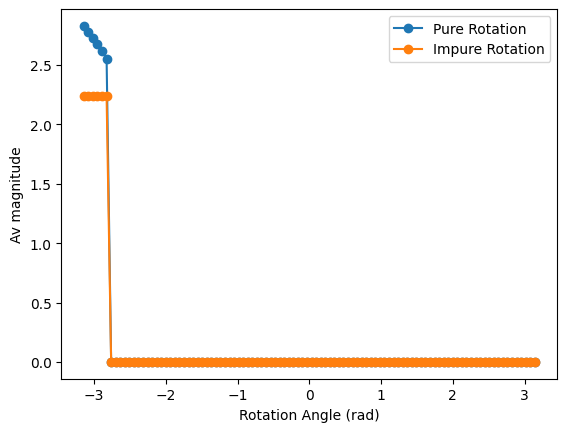

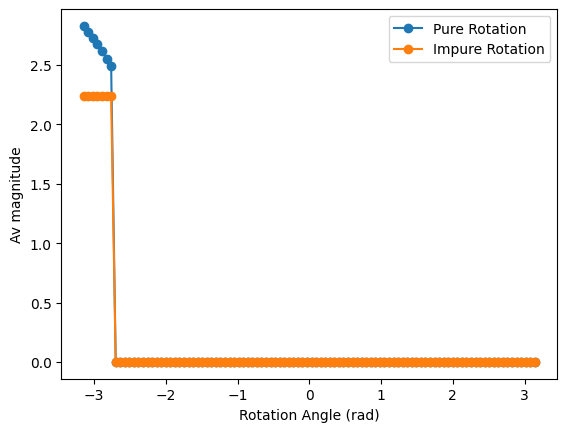

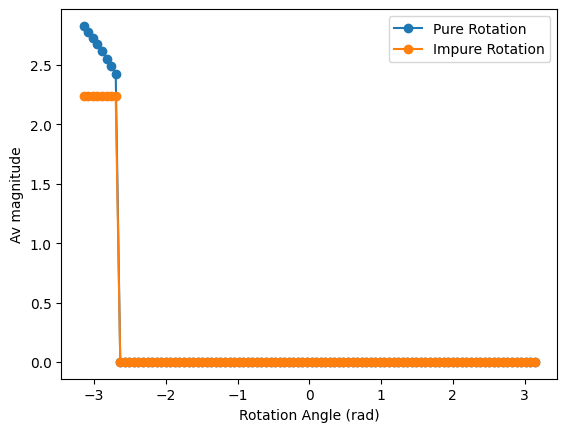

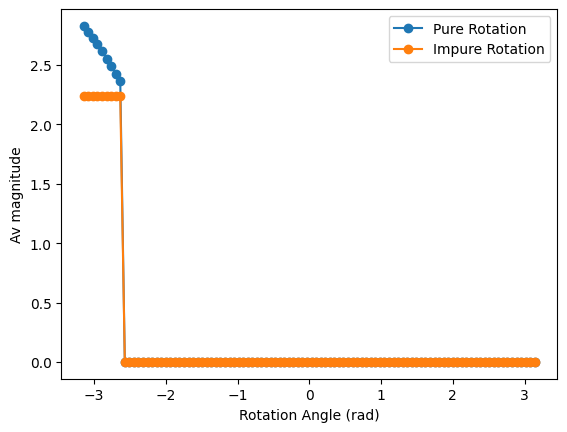

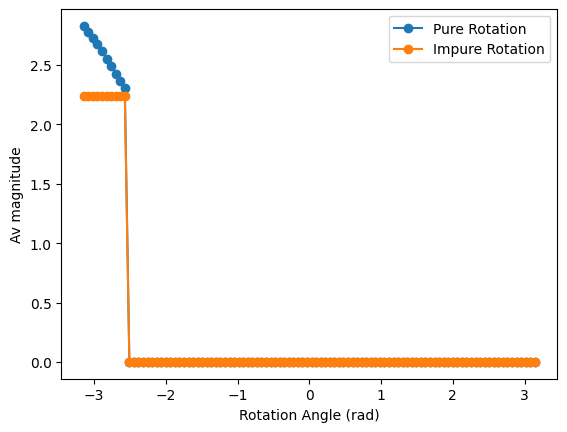

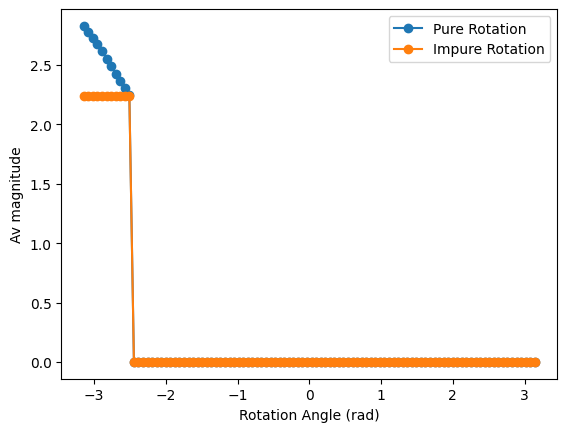

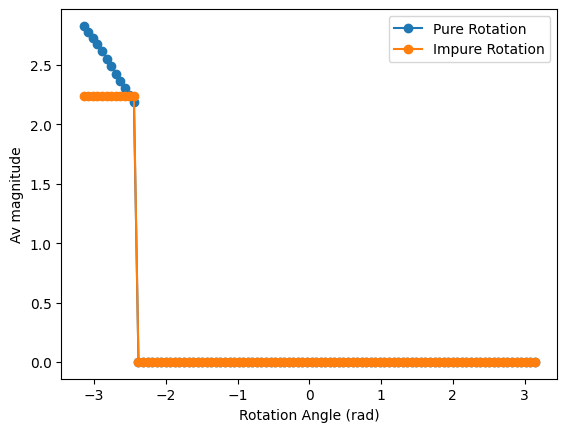

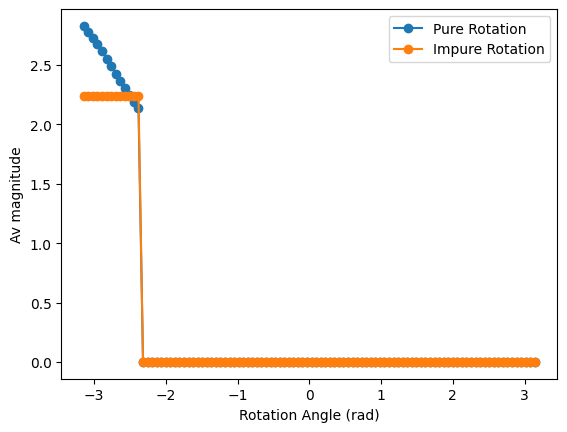

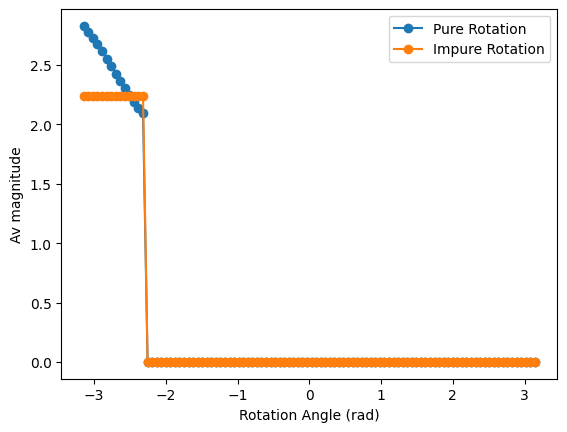

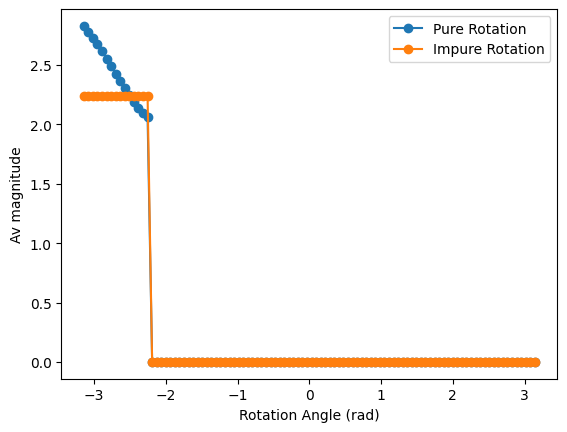

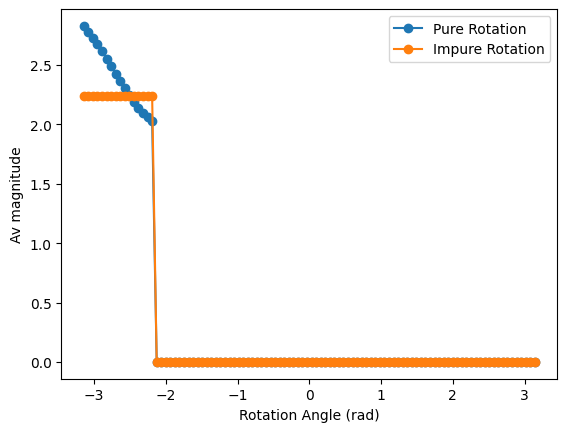

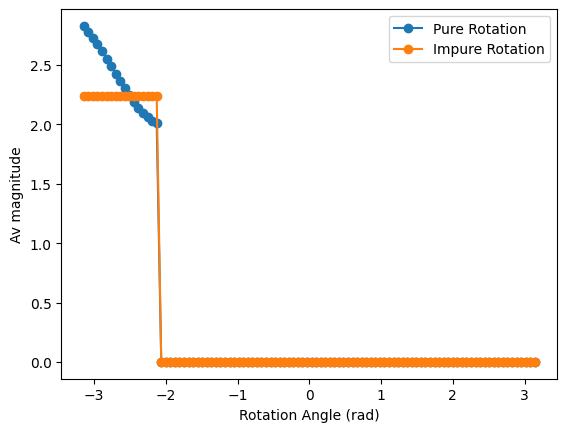

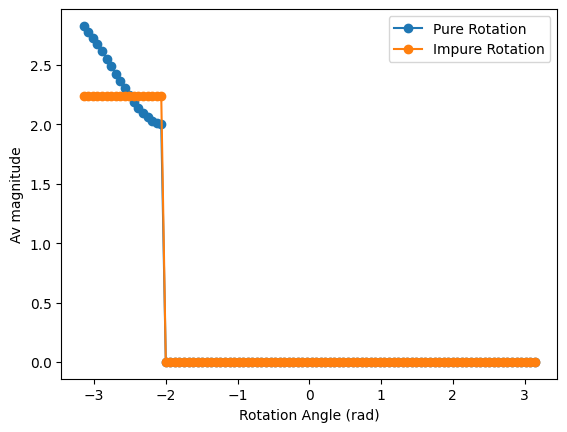

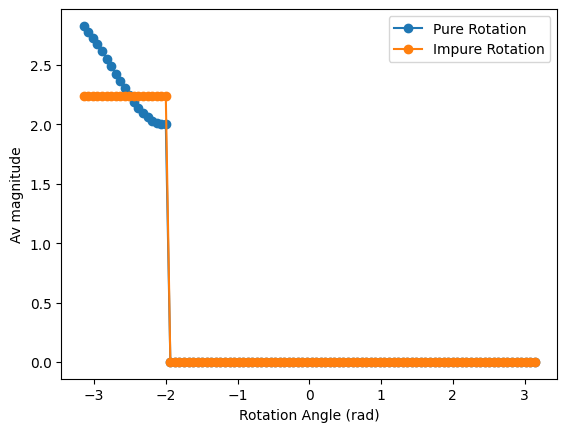

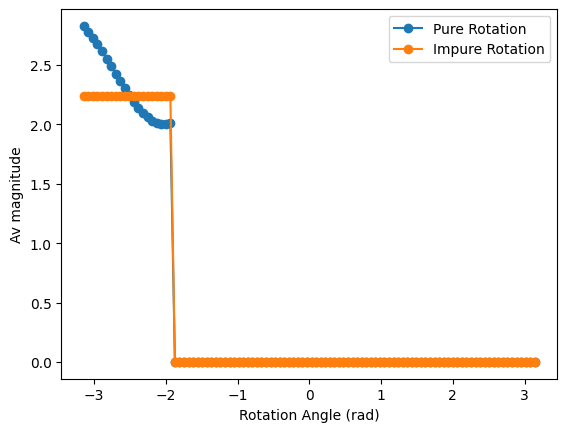

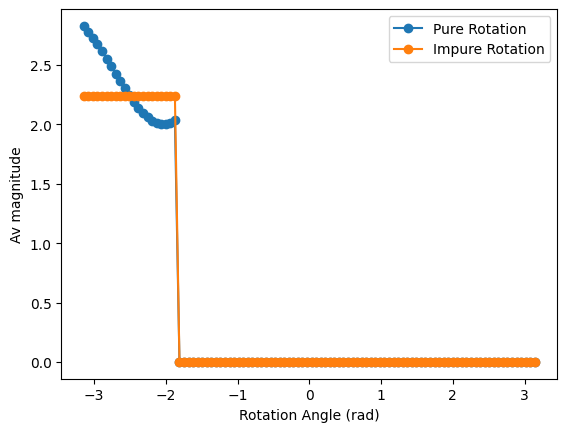

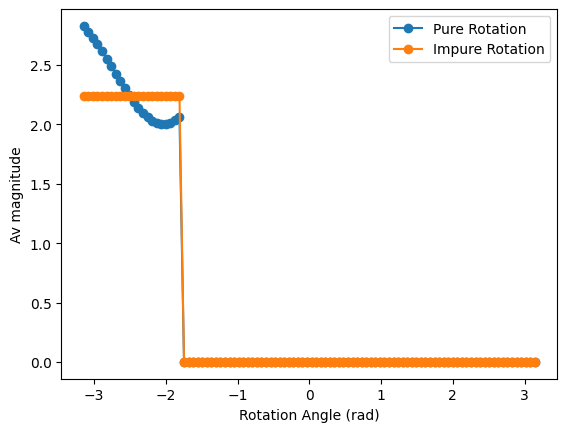

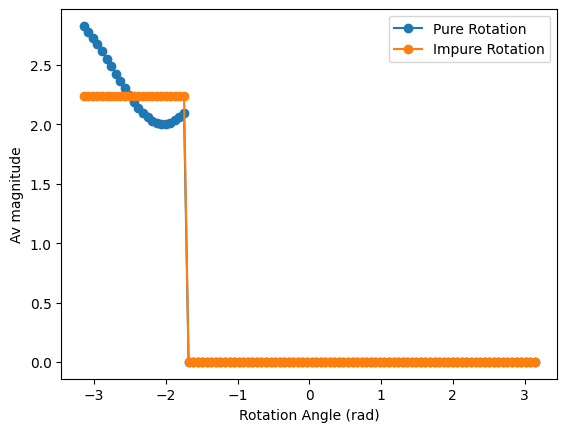

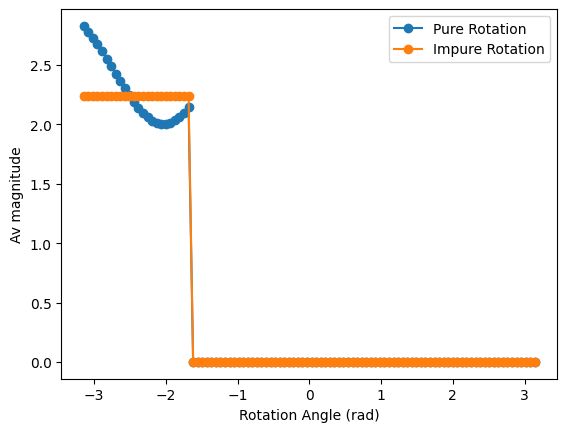

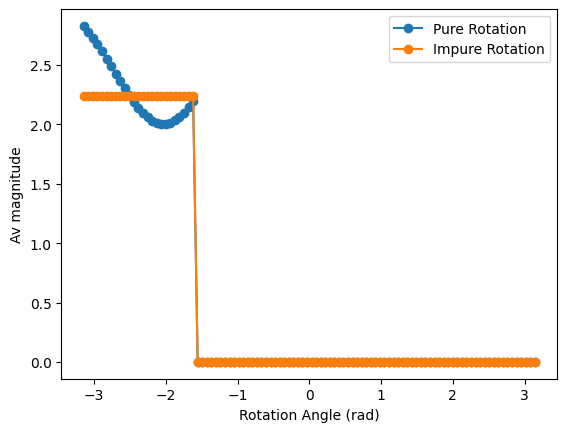

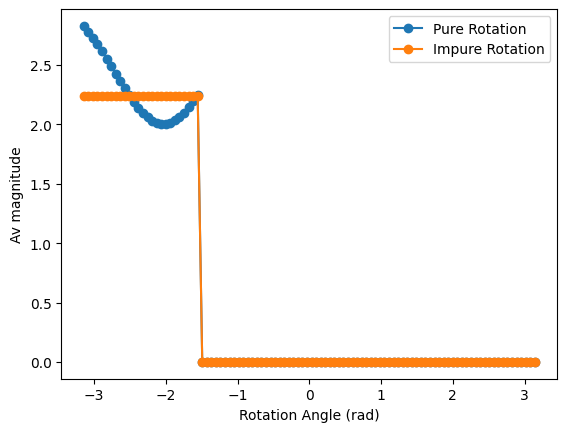

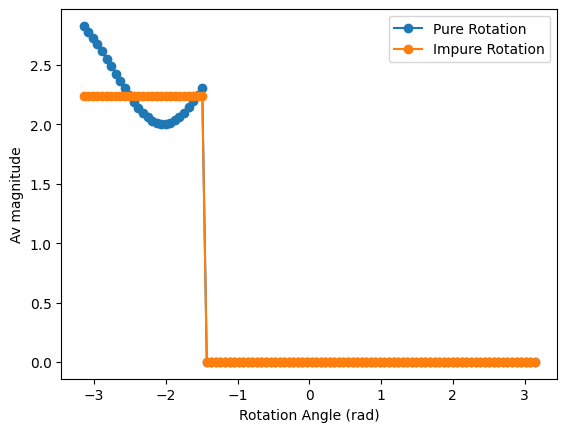

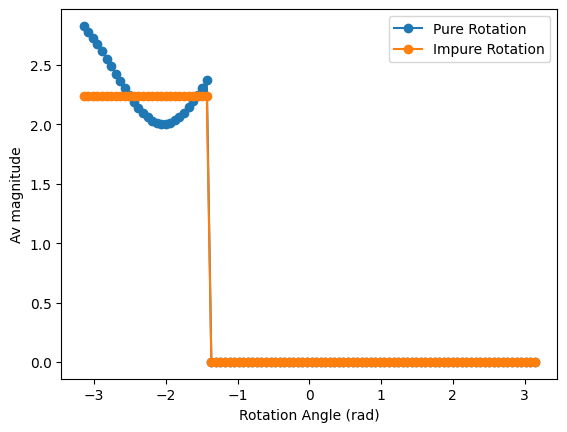

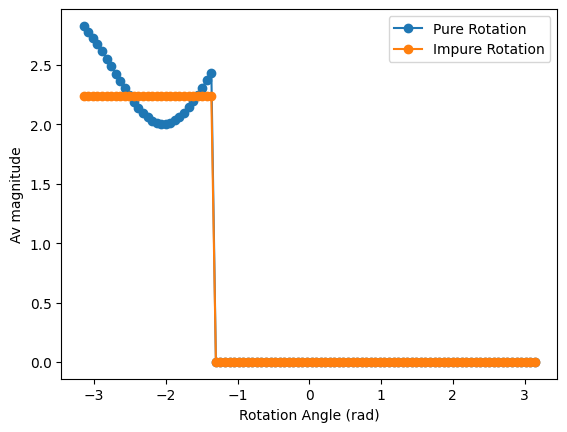

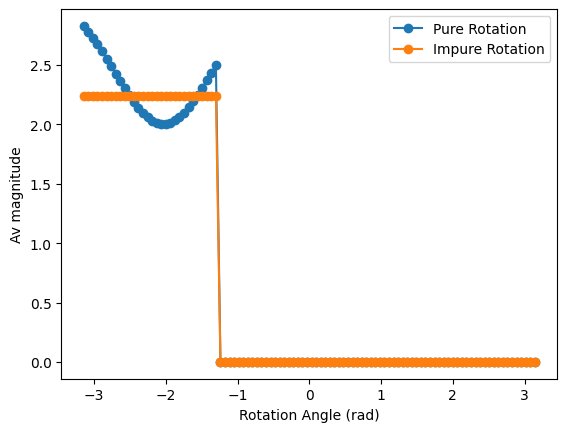

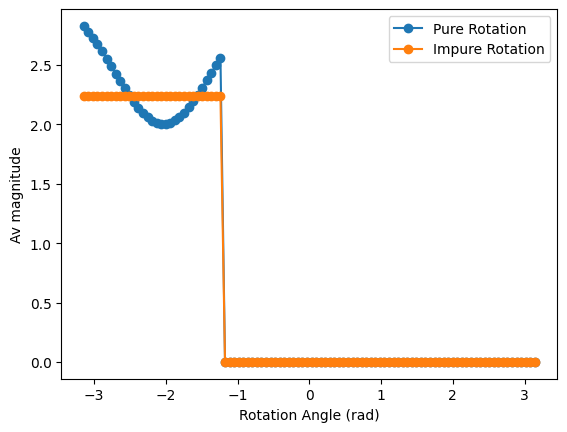

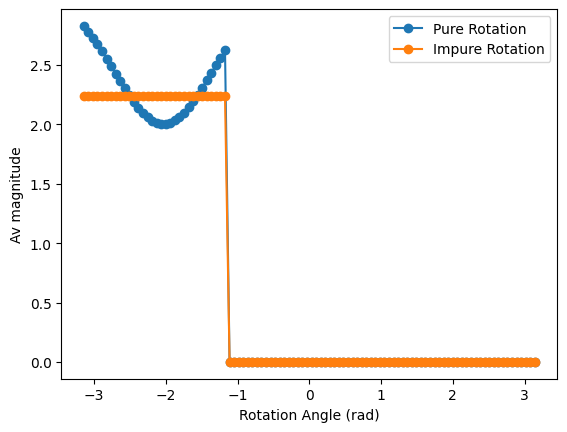

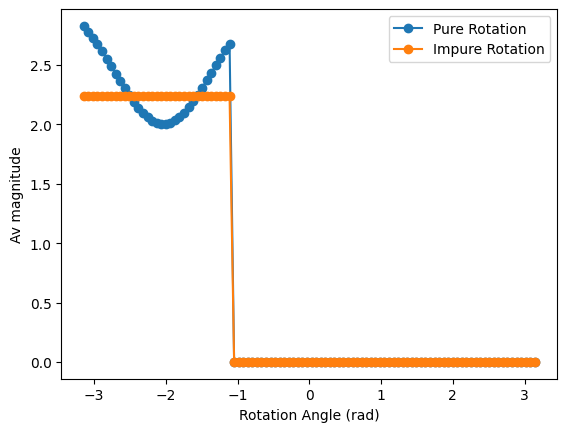

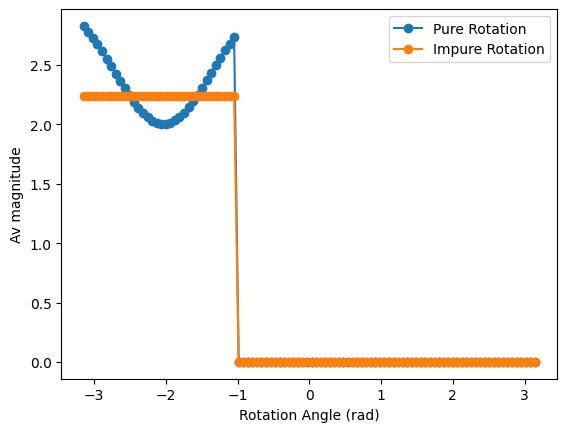

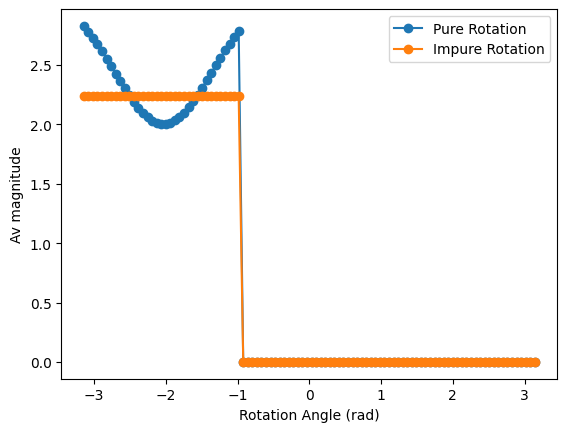

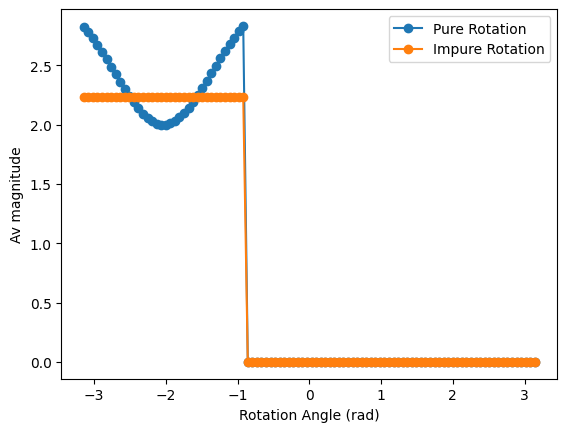

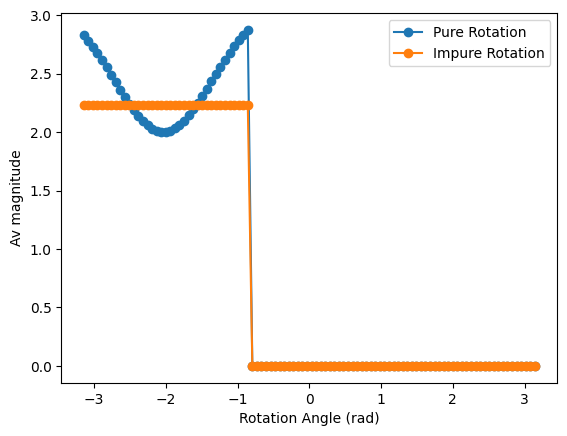

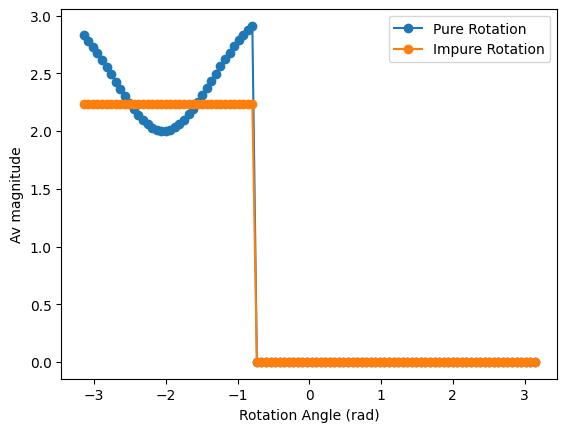

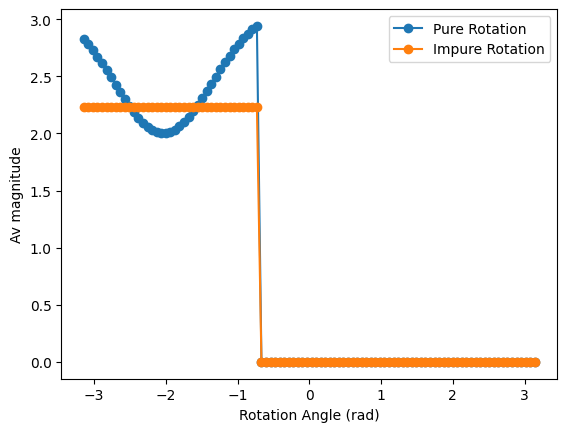

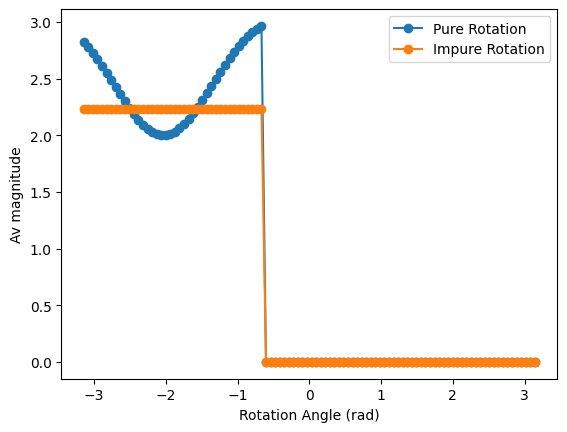

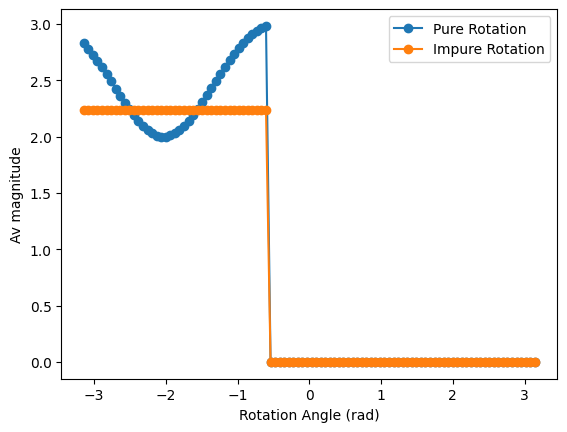

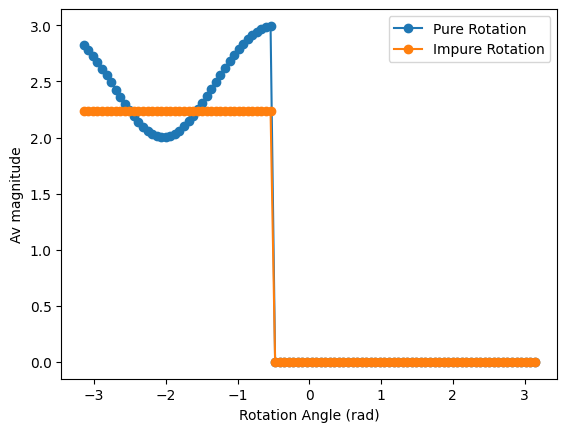

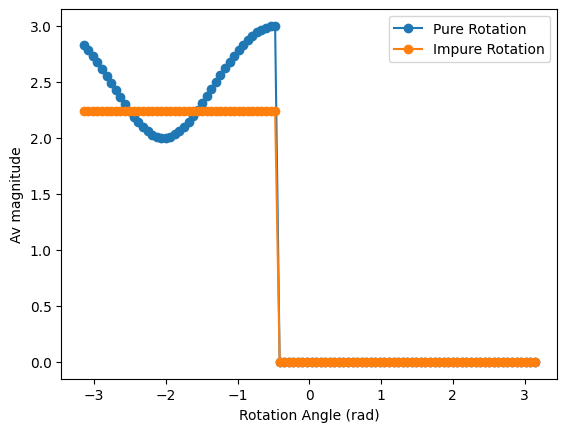

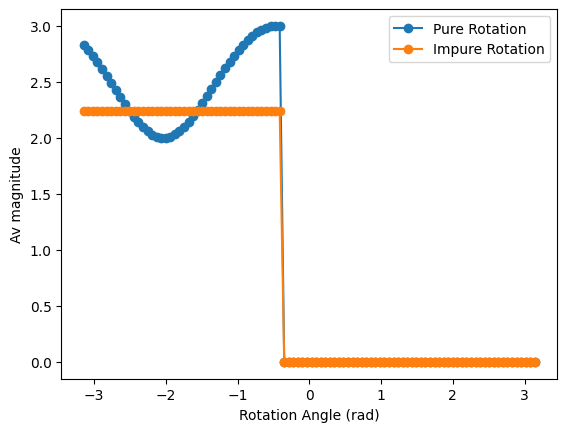

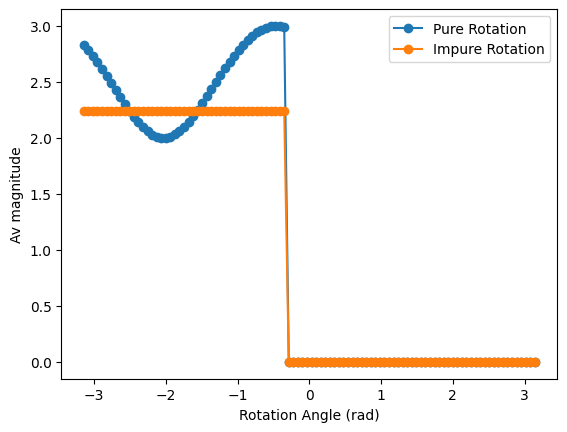

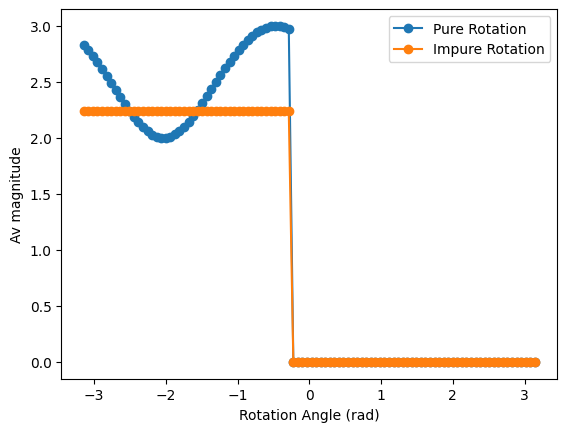

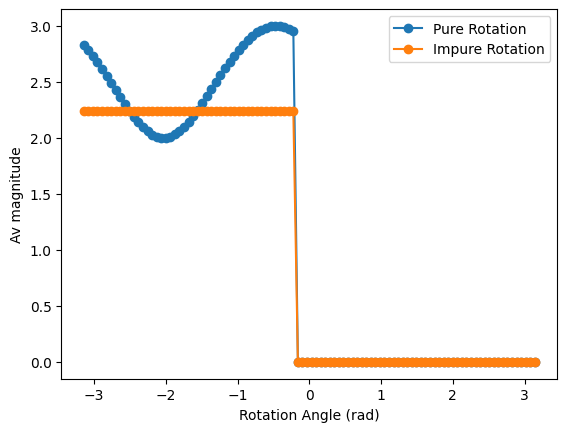

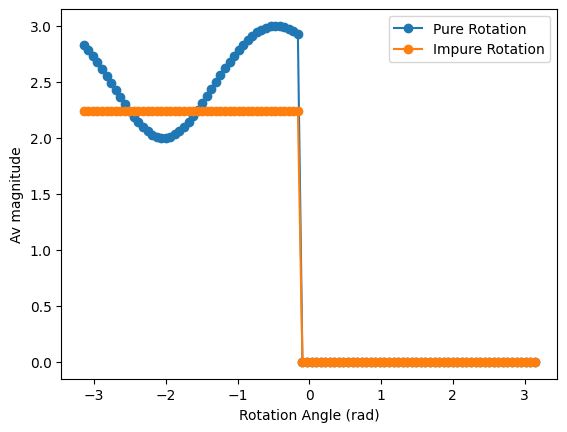

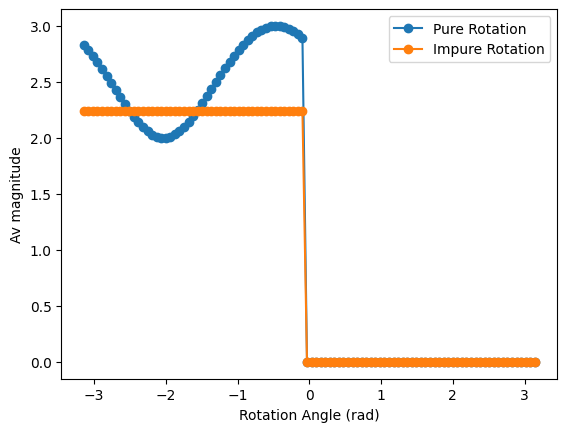

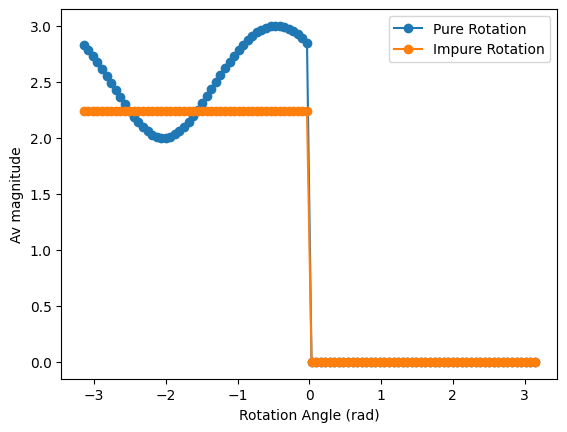

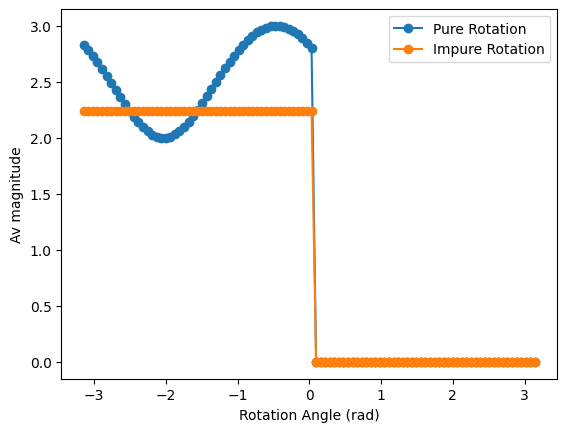

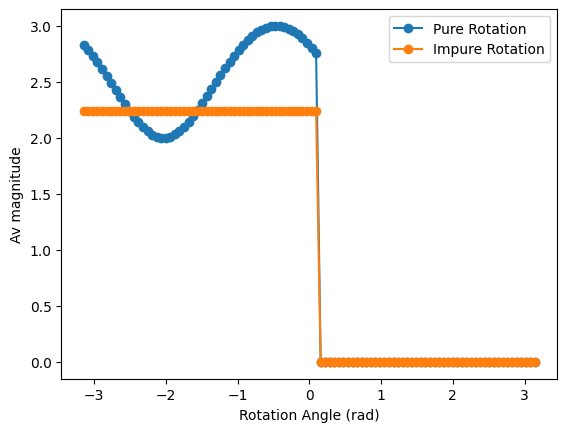

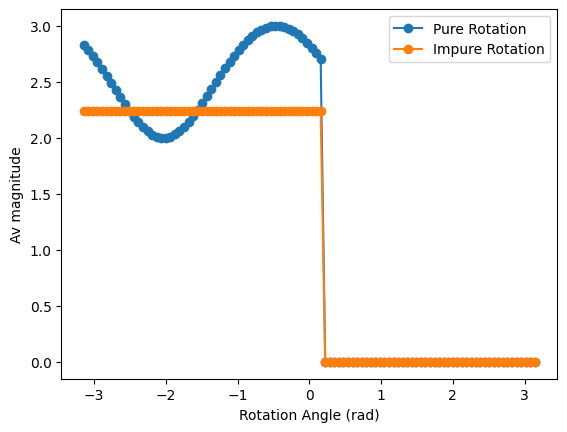

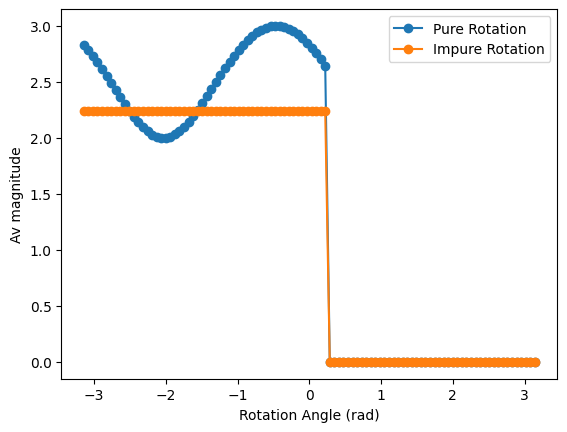

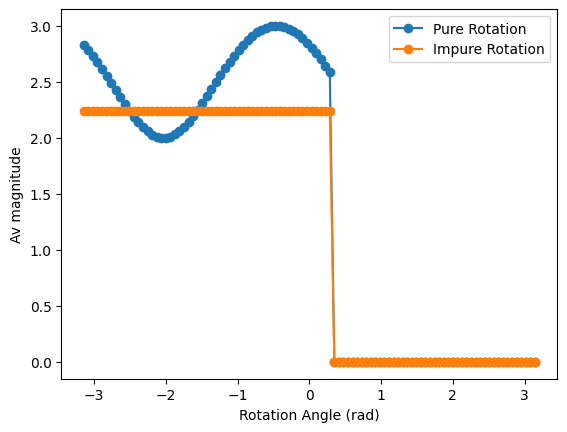

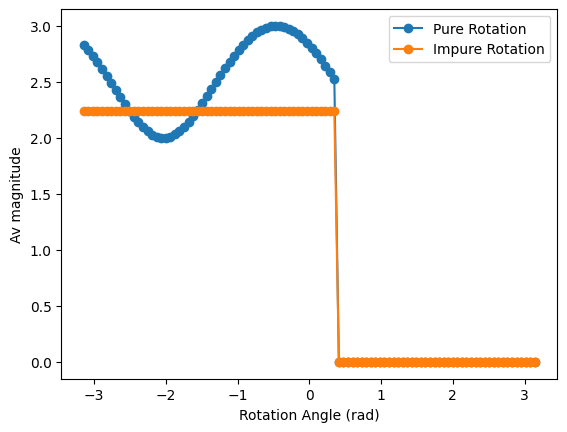

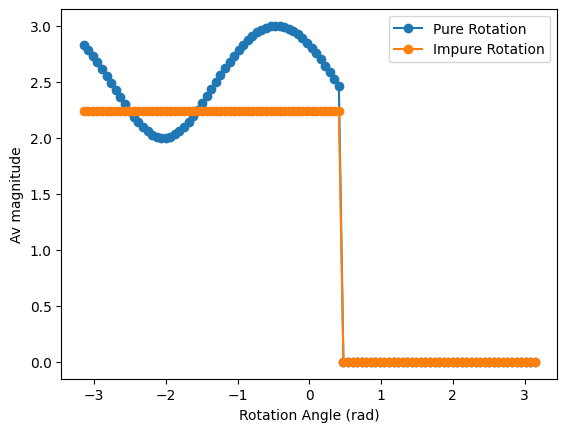

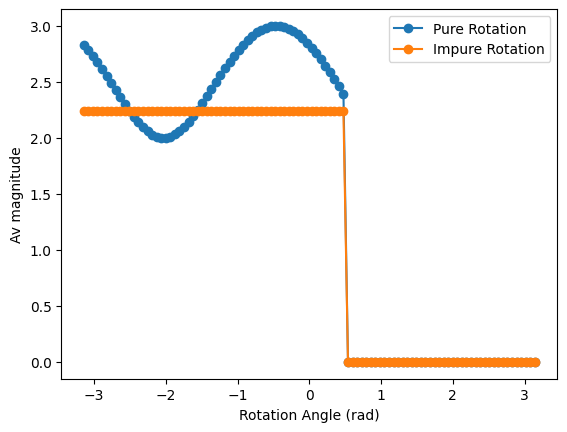

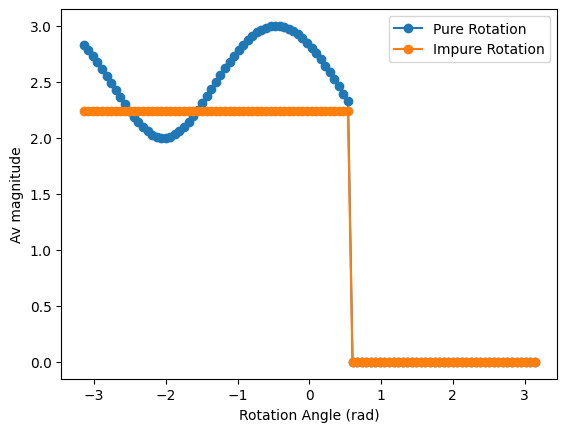

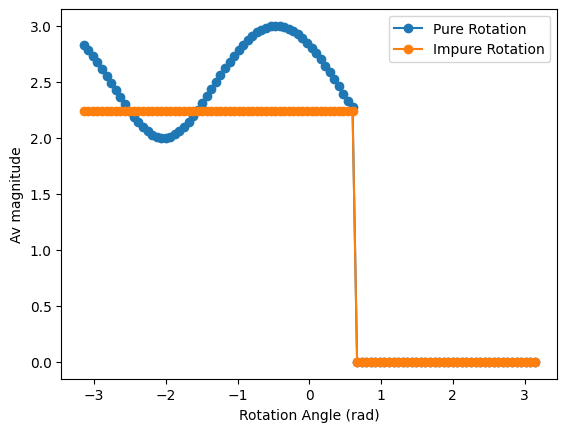

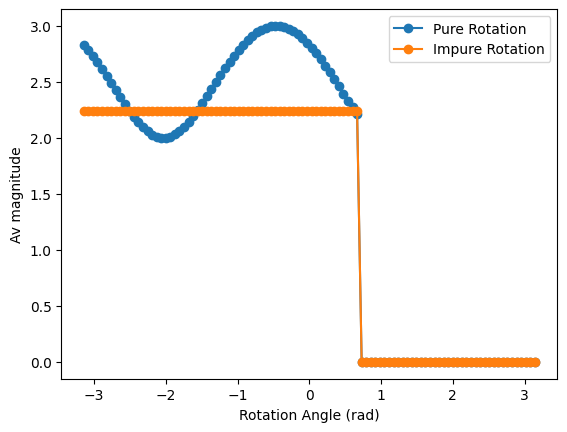

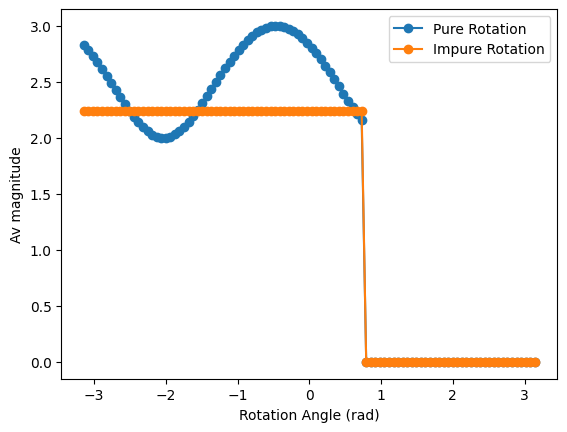

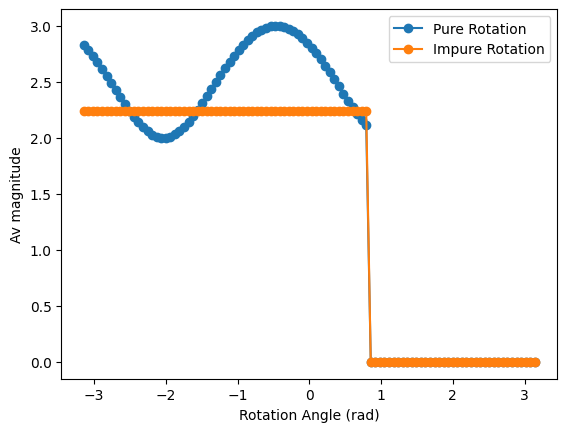

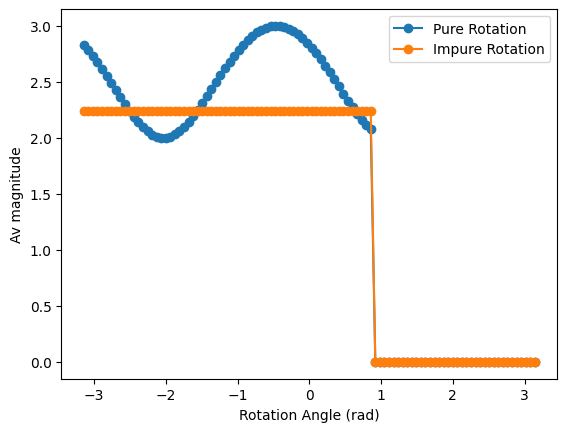

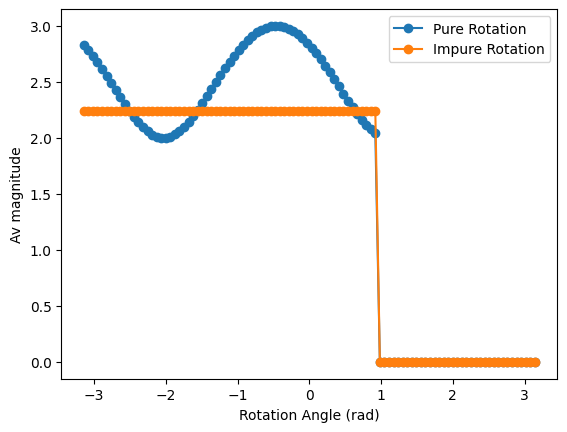

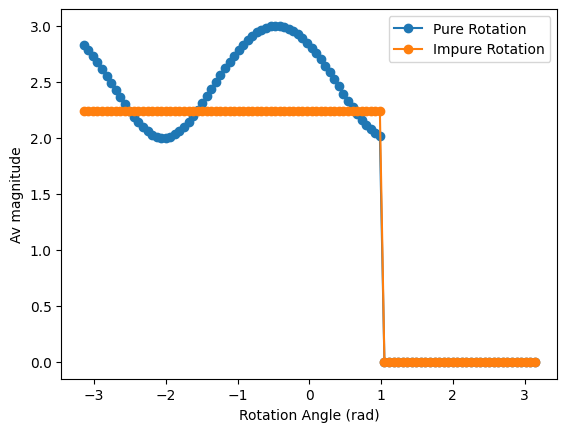

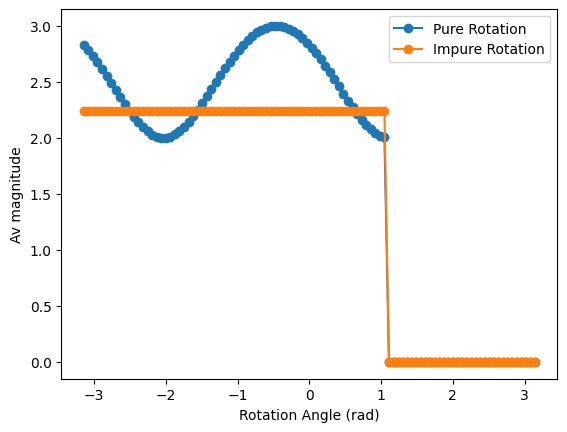

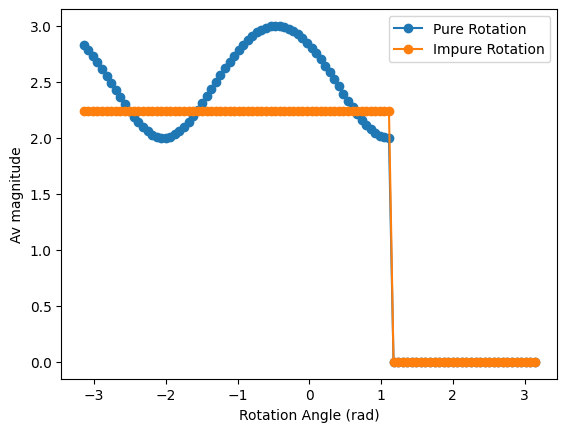

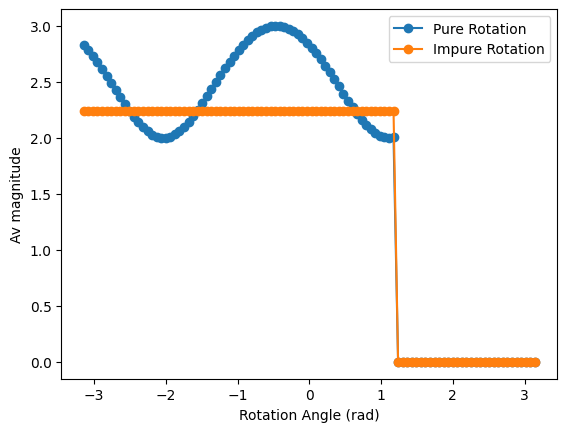

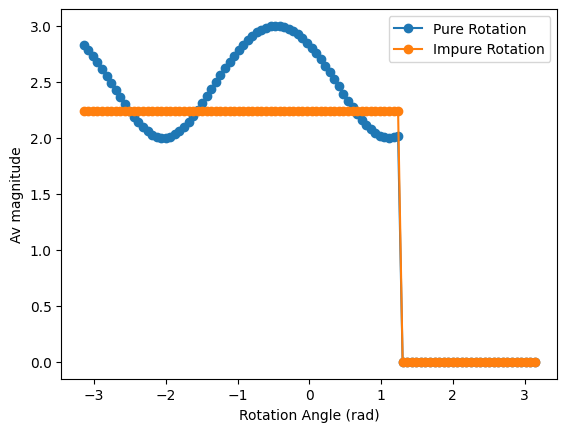

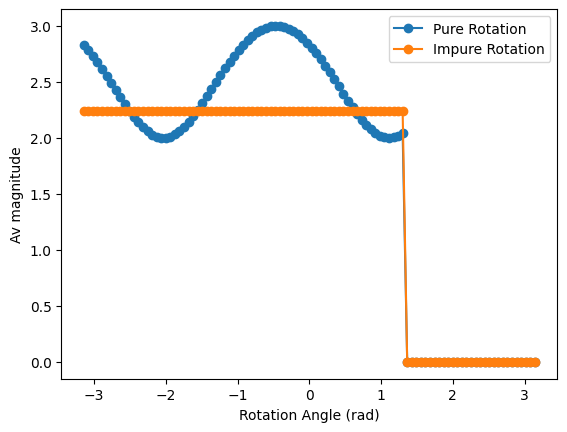

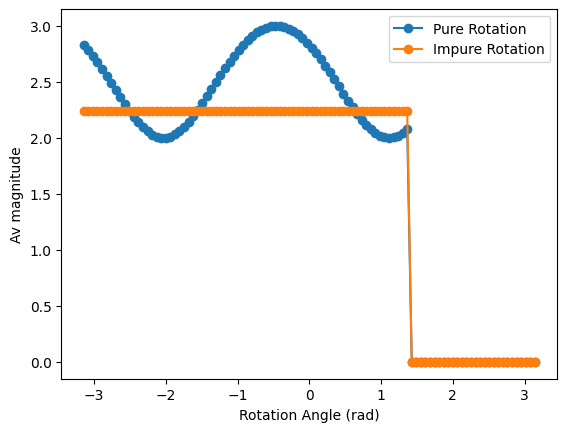

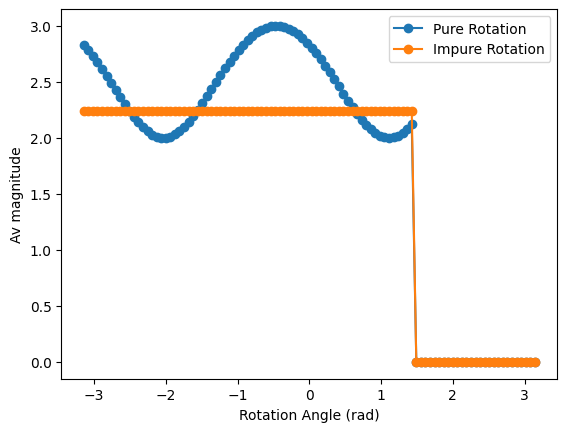

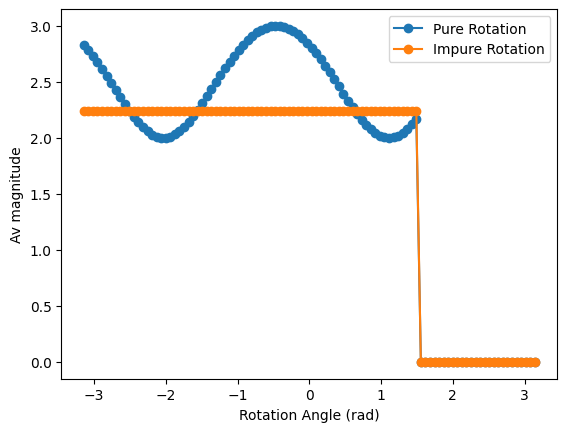

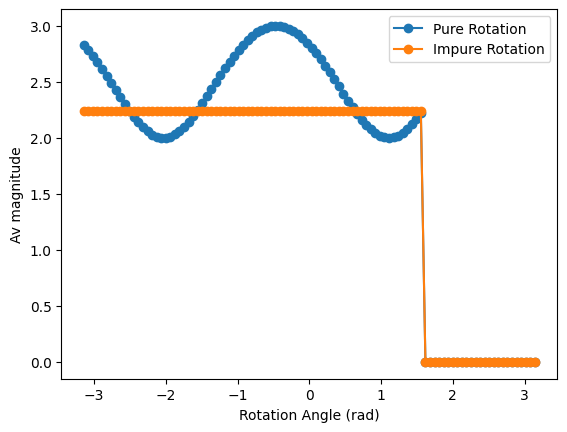

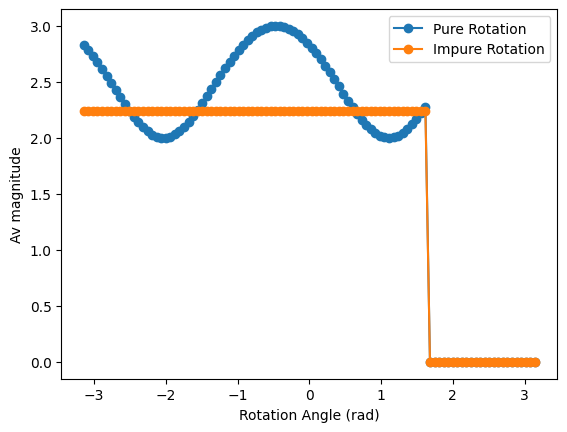

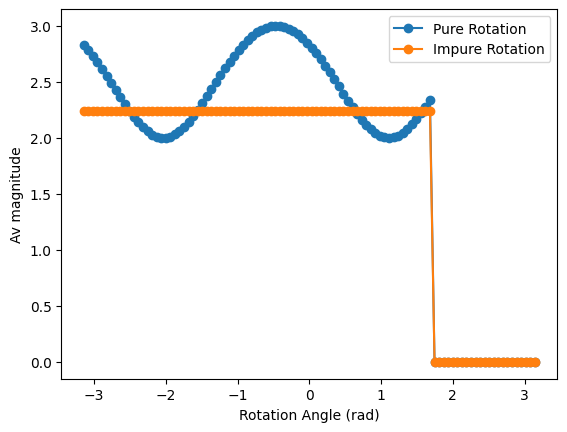

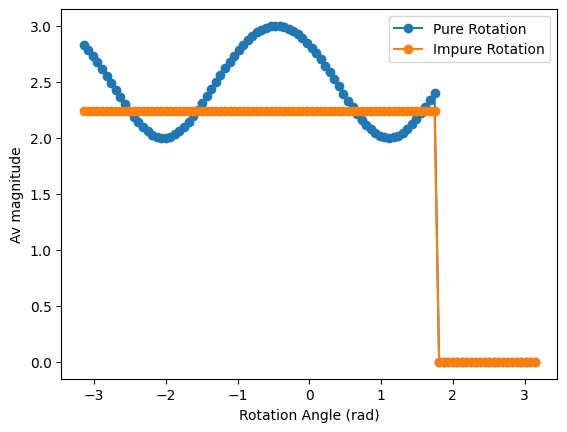

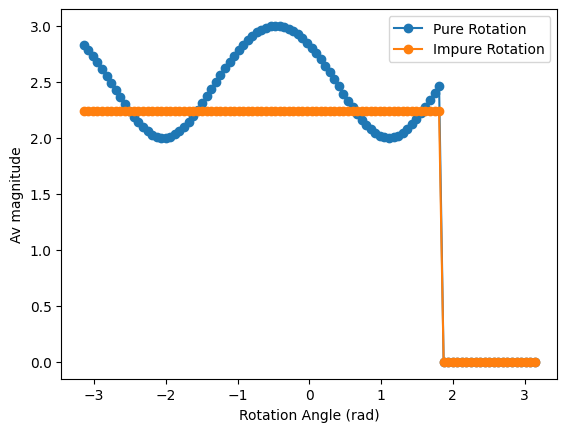

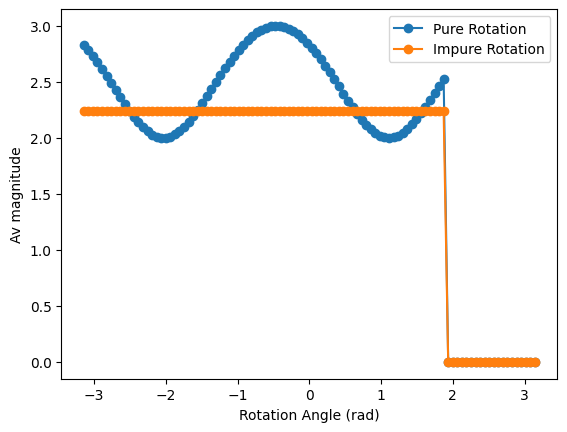

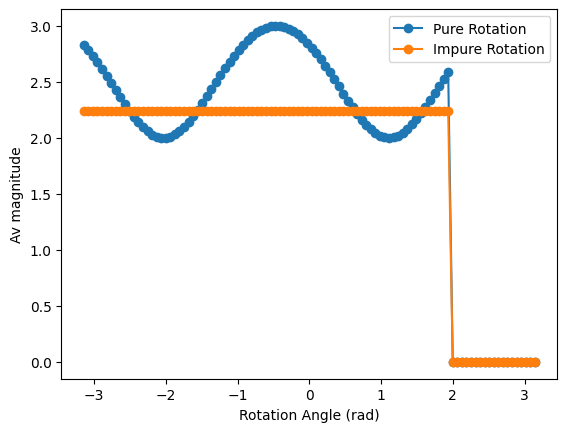

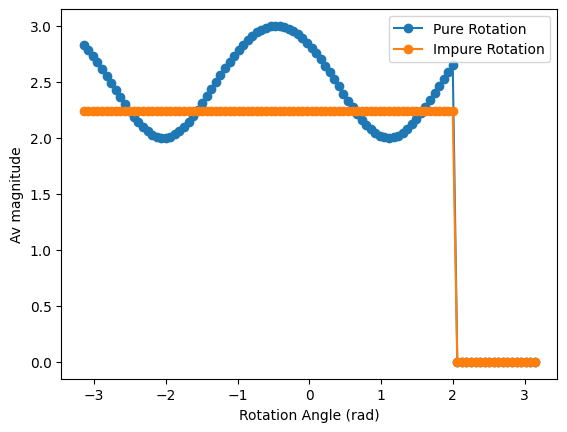

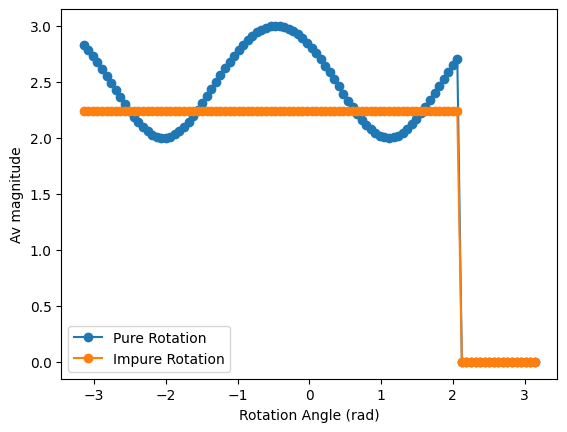

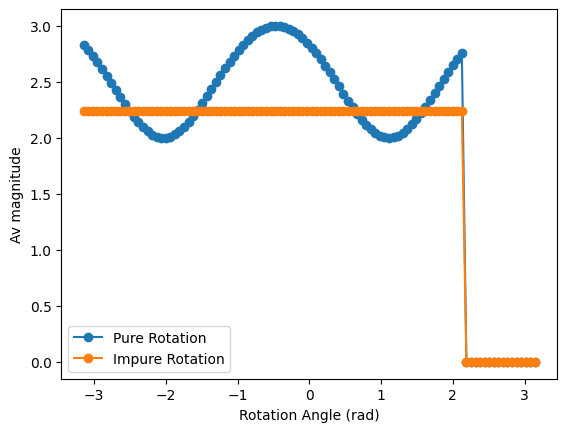

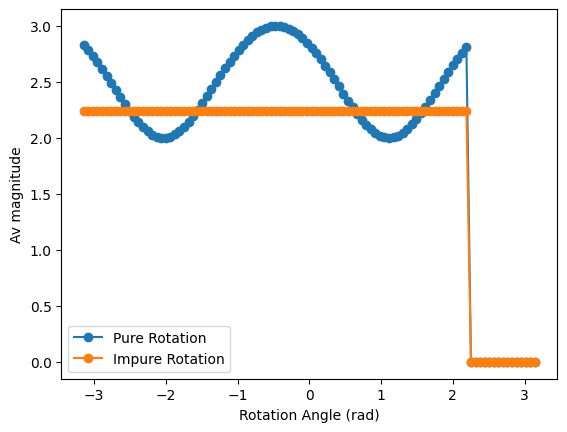

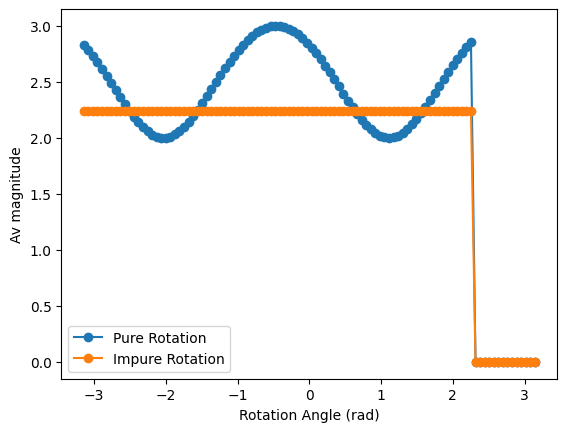

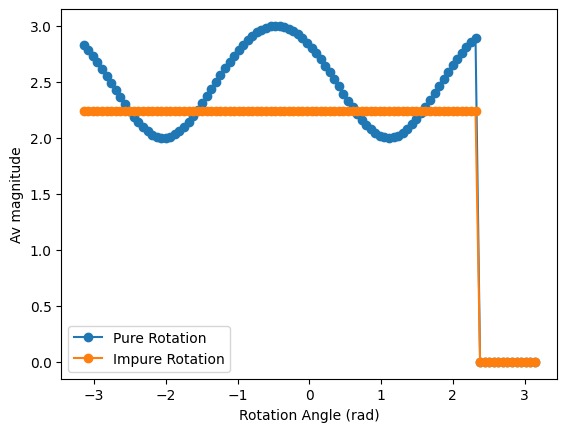

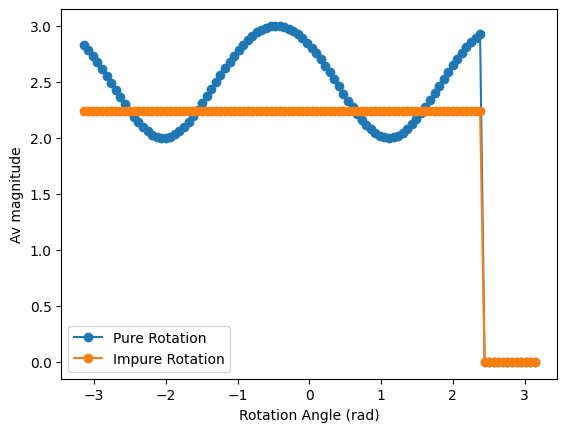

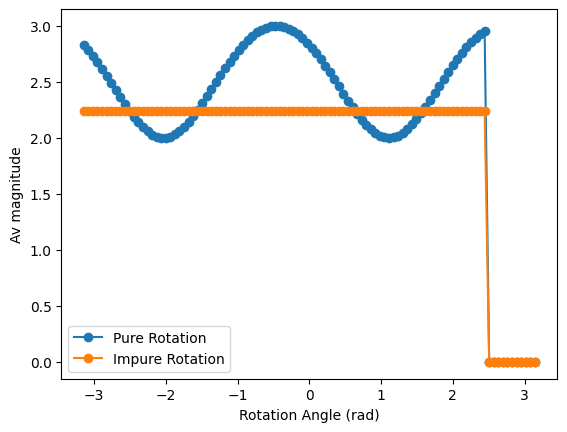

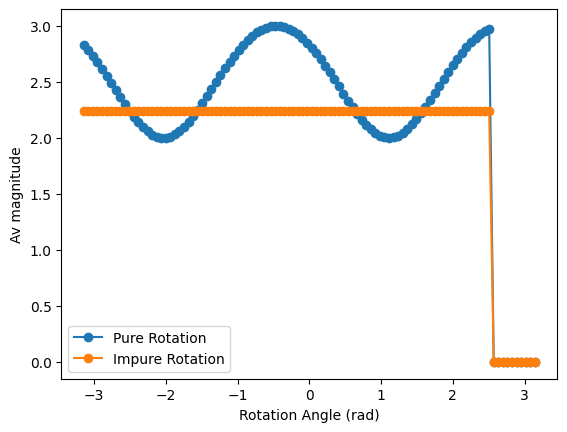

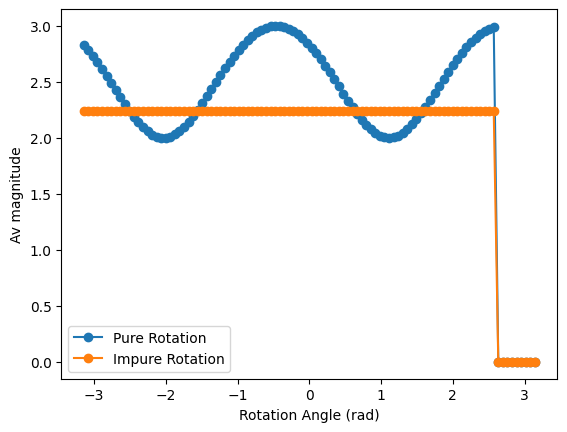

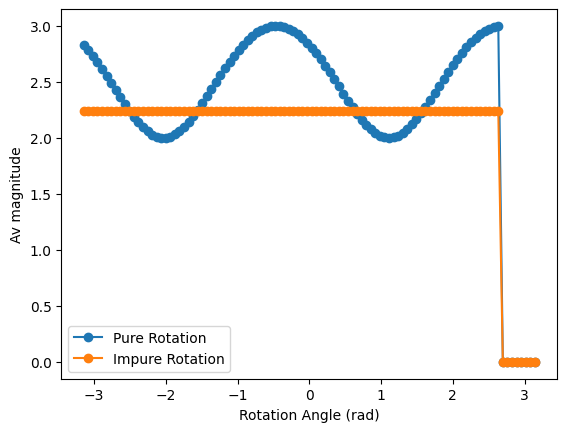

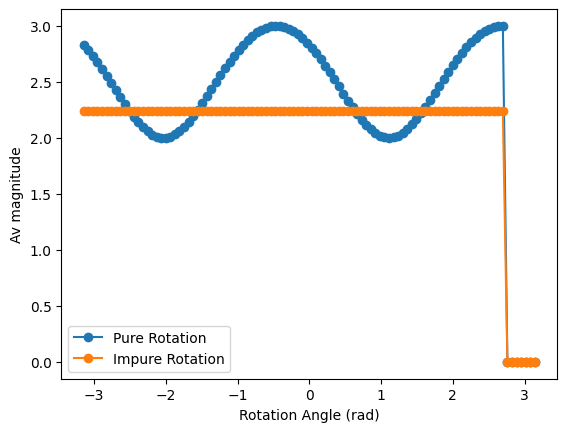

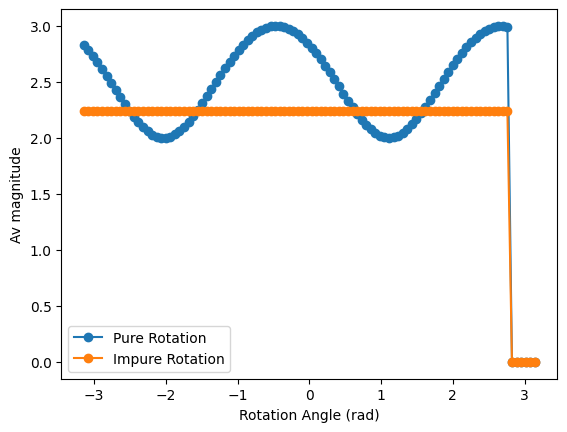

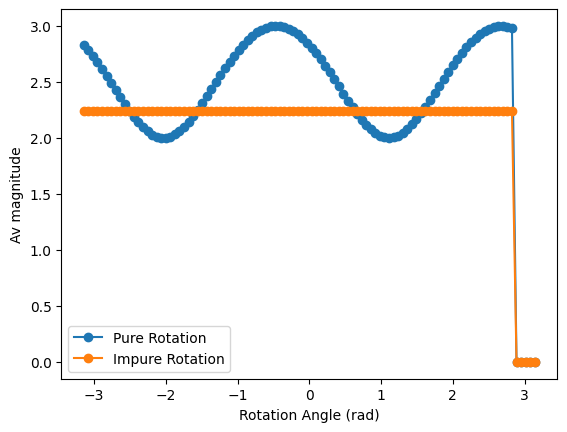

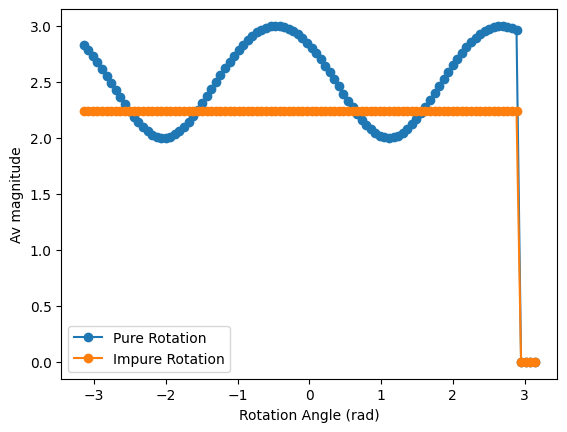

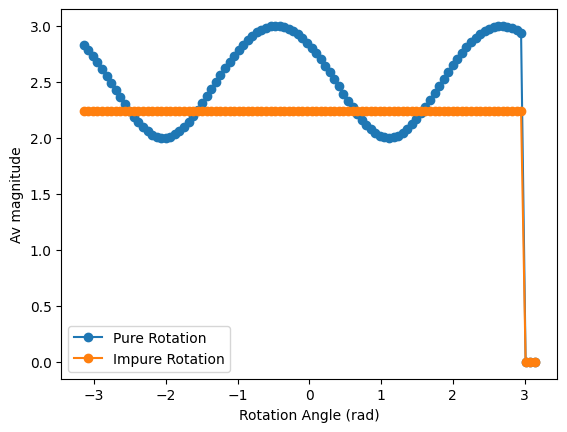

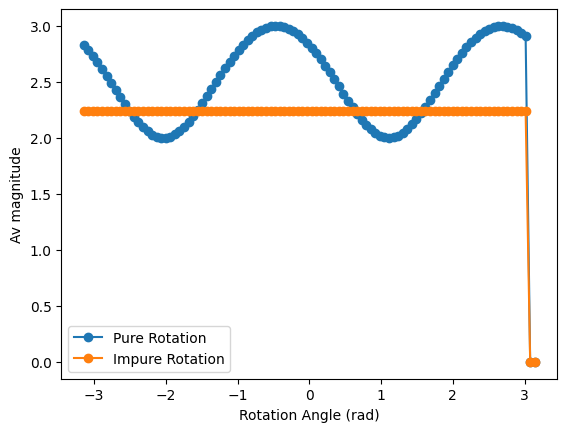

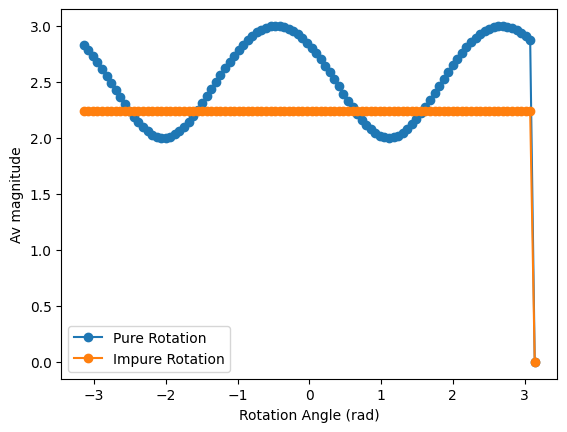

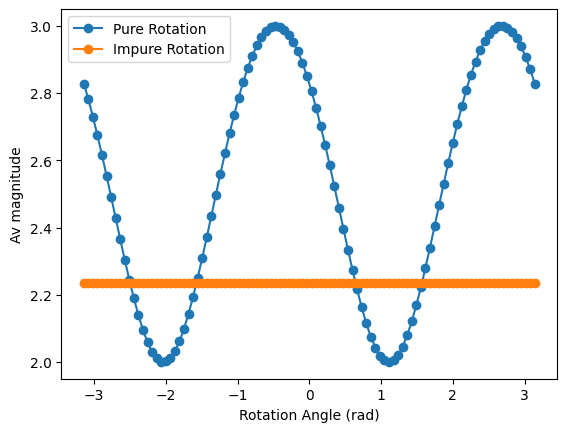

In [5]:
# --- Header: Pure vs. Impure Rotation Analysis ---
# Operation: Matrix-Vector Product + Euclidean Norm (L2)
# Loop: n = 100 (len(theta))
# Time Complexity: O(n)
#   - Each iteration performs constant time O(1) matrix operations (2x2).
# Space Complexity: O(n)
#   - Storing 100 magnitude pairs in the vmag array.
# Data Shape: vmag is (100, 2); theta is (100,)
# -------------------------------------------------

theta = np.linspace(-np.pi, np.pi, 100) # rotation angles
vmag = np.zeros((len(theta), 2)) # initialize output vector

for i in range(len(theta)):
    th = theta[i]
    P = np.array([ [math.cos(th), -math.sin(th)] , [math.sin(th), math.cos(th)] ]) # pure rotation matrix
    I = np.array([ [2*math.cos(th), -math.sin(th)], [math.sin(th), math.cos(th)] ]) # impure rotation matrix

    # compute vector magnitudes
    vmag[i, 1] = np.linalg.norm(P@v.T)
    vmag[i, 0] = np.linalg.norm(I@v.T)

    plt.plot(theta, vmag, 'o-')
    plt.xlabel('Rotation Angle (rad)')
    plt.ylabel('Av magnitude')
    plt.legend(['Pure Rotation', 'Impure Rotation'])
    plt.show()

### Code Challenge: Geometric Transformations via Matrix Multiplications

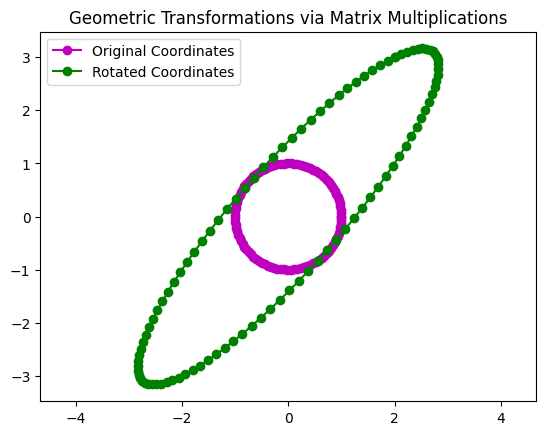

In [40]:
# --- Header: Dynamic Axis Scaling ---
# Operation: Array Flattening, Concatenation, and Absolute Max
# Time Complexity: O(n) where n is the total number of elements in xy and xy_rotated.
#   - np.append: O(n)
#   - np.abs: O(n)
#   - np.max: O(n)
# Space Complexity: O(n) to store the intermediate appended array.
# Logic: Ensures the transformation visualization remains centered at (0,0).
# ------------------------------------

# xy coordinates for a circle
x = np.linspace(0, 2*np.pi, 100)
xy = np.vstack((np.cos(x), np.sin(x))).T

# plot the circle
plt.plot(xy[:, 0], xy[:, 1], 'o-', color='m')

# 2x2 matrix
A = np.array([ [2, 3], [2, 1] ])

# multiply the matrix by the coordinates
xy_rotated = xy@A

# plot the new coordinates
plt.plot(xy_rotated[:, 0], xy_rotated[:, 1], 'o-', color='g')

# adjust the plot
limit = np.max(np.abs(np.append(xy_rotated, xy)))
plt.axis([-limit, limit, -limit, limit])
plt.axis('equal')
plt.title('Geometric Transformations via Matrix Multiplications')
plt.legend(['Original Coordinates', 'Rotated Coordinates'])
plt.show()